In [1]:
# 라이브러리 & 기본 옵션

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

# 1) 윈도우 기본 맑은고딕 파일 경로
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 2) 폰트를 matplotlib에 "강제 등록"
fm.fontManager.addfont(font_path)

# 3) 등록한 폰트의 정확한 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 4) matplotlib + seaborn 둘 다에 폰트 강제 적용 (seaborn이 덮는 문제 방지)
mpl.rcParams["font.family"] = font_name
mpl.rcParams["font.sans-serif"] = [font_name]
mpl.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", rc={
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "axes.unicode_minus": False
})

***

In [2]:
# 0) 데이터 로드
df = pd.read_csv("../data/survey_response.csv")

# 데이터 확인
df.head(1)

,gender,age_group,region,cafe_visits_per_week,starbucks_visits_per_week,reserve_awareness_flag,reserve_awareness_channel,reserve_visited_flag,reserve_visit_purpose,reserve_service_used,reserve_service_reuse_flag,reserve_nonvisit_reason,reserve_ab_group,reserve_perception_change,reserve_improvement,reserve_recommend
0,여,20대,경기,2~3회,0~1회,Yes,"스타벅스 앱 / 매장(포스터, 이벤트)",Yes,일상적인 커피·음료 구매 목적 → 단순 가까운 위치/동선 상 편리해서,"리저브 전용 서비스를 이용하지 않음 (바 좌석 이용 X , 전용 음료 X)",No,NaN,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,가격 인하,5


**컬럼 정보**
- `gender` : 성별 (unique ID)
- `age_group` : 연령대
- `region` : 거주 지역
- `cafe_visits_per_week` : 주 평균 카페 방문 횟수
- `starbucks_visits_per_week` : 주 평균 스타벅스 방문 횟수
- `reserve_awareness_flag` : 리저브 인지 여부
- `reserve_awareness_channel` : 리저브 유입 경로
- `reserve_visited_flag` : 리저브 방문 경험
- `reserve_visit_purpose` : 리저브 방문 목적
- `reserve_service_used` : 리저브 전용 서비스 이용 경험
- `reserve_service_reuse_flag` : 리저브 전용 서비스 재이용 의사
- `page_coreserve_nonvisit_reasonnfirm` : 리저브 미방문 이유
- `reserve_ab_group` : 리저브 A/B 테스트
- `reserve_perception_change` : 리저브 인식 전환
- `reserve_improvement` : 리저브 개선 요구
- `reserve_recommend` : 리저브 추천 의향

***

### 📌 가설: (H06-1, 2)
- (H06-1) `A 집단`과 `B 집단`의 `방문 의향 점수 분포`(또는 중앙값)에 유의한 `차이가 없을 것이다`.<br><br>
- (H06-2) `A 집단`과 `B 집단`의 `추천 의향 점수 분포`(또는 중앙값)에 유의한 `차이가 없을 것이다`.

In [3]:
# 1) 필요한 컬럼만 뽑기
# - A/B 그룹: reserve_ab_group
# - 방문 의향: reserve_perception_change (1~5)
# - 추천 의향: reserve_recommend (1~5)
use_cols = ["reserve_ab_group", "reserve_perception_change", "reserve_recommend"]
df_ab = df[use_cols].copy()
df_ab.head(3)

,reserve_ab_group,reserve_perception_change,reserve_recommend
0,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5
1,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,4,4
2,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5


***

In [4]:
# 2) 전처리
# 2-1) 결측치 확인
df_ab.isna().sum()

reserve_ab_group             0
reserve_perception_change    0
reserve_recommend            0
dtype: int64

In [5]:
# 2-2) A/B 그룹이 비어있는 행 제거
# 공백제거 + 문자열로 통일
df_ab["reserve_ab_group"] = df_ab["reserve_ab_group"].astype(str).str.strip()

# 결측치 제거
df_ab = df_ab[df_ab["reserve_ab_group"].notna()]

# 빈 문자열 제거
df_ab = df_ab[df_ab["reserve_ab_group"] != ""]

# nan 문자열 제거
df_ab[~df_ab["reserve_ab_group"].str.contains("nan", case=False, na=False)]

,reserve_ab_group,reserve_perception_change,reserve_recommend
0,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5
1,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,4,4
2,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5
3,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5
4,A안 - 프리미엄 커피/전문성(원두·추출) : 원두 종류 다양성 + 바,5,3
...,...,...,...
195,A안 - 프리미엄 커피/전문성(원두·추출) : 원두 종류 다양성 + 바,3,2
196,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,4,3
197,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,4,3
198,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,4


In [6]:
df_ab.isna().sum()

reserve_ab_group             0
reserve_perception_change    0
reserve_recommend            0
dtype: int64

In [7]:
# 2-3) 그룹 라벨을 A/B로 단순화
df_ab["group"] = np.where(df_ab["reserve_ab_group"].str.contains("A안"), "A", "B")
df_ab.head(3)

,reserve_ab_group,reserve_perception_change,reserve_recommend,group
0,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5,B
1,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,4,4,B
2,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,5,B


In [8]:
# 2-4) 점수 컬럼 숫자로 변환 (문자면 NaN될 수 있음)
for col in ["reserve_perception_change", "reserve_recommend"]:
    df_ab[col] = pd.to_numeric(df_ab[col], errors="coerce")

In [9]:
# 2-5) 점수가 없는 행 제거
df_ab = df_ab.dropna(subset=["reserve_perception_change", "reserve_recommend"])
df_ab.count()

reserve_ab_group             200
reserve_perception_change    200
reserve_recommend            200
group                        200
dtype: int64

***

In [10]:
# 3) 표본 수 확인
print("A/B 표본 수")
print(df_ab["group"].value_counts())

A/B 표본 수
group
B    146
A     54
Name: count, dtype: int64


***

In [11]:
# 4) 기술통계(평균/중앙값/표준편차 + top-box 비율)
def summarize_by_group(df, score_col):
    out = df.groupby("group")[score_col].agg(
        n="count",
        mean="mean",
        median="median",
        std="std"
    )
    out["topbox_4_5_rate"] = df.groupby("group")[score_col].apply(lambda s: (s >= 4).mean())
    return out

print("\n[방문 의향 점수 분포] 기술통계")
print(summarize_by_group(df_ab, "reserve_perception_change"))

print("\n[추천 의향 점수 분포] 기술통계")
print(summarize_by_group(df_ab, "reserve_recommend"))


[방문 의향 점수 분포] 기술통계
         n      mean  median       std  topbox_4_5_rate
group                                                  
A       54  3.481481     3.0  1.284754         0.444444
B      146  3.801370     4.0  1.073954         0.657534

[추천 의향 점수 분포] 기술통계
         n      mean  median       std  topbox_4_5_rate
group                                                  
A       54  3.166667     3.0  1.209241         0.370370
B      146  3.253425     3.0  0.967126         0.363014


#### ☑️ 기술통계 정리
1. <span style="color:orange">[방문 의향 점수 분포] 기술통계</span>

|<span style="color:red">group</span>|<span style="color:skyblue">개수</span>(count)|<span style="color:skyblue">평균</span>(mean)|<span style="color:skyblue">중앙값</span>(median)|<span style="color:skyblue">표준편차</span>(std)|<span style="color:skyblue">긍정 응답률(4~5점)</span>(topbox_4_5_rate)|
|:---:|:---:|:---:|:---:|:---:|:---:|
|<span style="color:red">**A**</span>|54개(`27%`)|3.48|3.0|1.28|44.4%|
|<span style="color:red">**B**</span>|146개(`73%`)|3.80|4.0|1.07|65.7%|

2. <span style="color:orange">[추천 의향 점수 분포] 기술통계</span>

|<span style="color:red">group</span>|<span style="color:skyblue">개수</span>(count)|<span style="color:skyblue">평균</span>(mean)|<span style="color:skyblue">중앙값</span>(median)|<span style="color:skyblue">표준편차</span>(std)|<span style="color:skyblue">긍정 응답률(4~5점)</span>(topbox_4_5_rate)|
|:---:|:---:|:---:|:---:|:---:|:---:|
|<span style="color:red">**A**</span>|54개(`27%`)|3.16|3.0|1.20|37.0%|
|<span style="color:red">**B**</span>|146개(`73%`)|3.25|3.0|0.96|36.3%|

***

##### 💡 검정: Mann–Whitney U
  - `목적`: 두 독립 집단(A/B) 간 점수 분포(중앙값/순위) 차이 검정.
  - `이유`: 1~5점 리커트는 순서형이며 정규성 가정이 애매 → 비모수 검정이 적합.
  - `해석`: 
    - p < 0.05 → 유의한 차이가 있다(귀무가설 기각)
    - p ≥ 0.05 → 유의한 차이라고 보기 어렵다(귀무가설 기각 실패)

In [12]:
#  5) 비모수 검정: Mann–Whitney U
def mann_whitney_test(df, score_col):
    a = df.loc[df["group"] == "A", score_col]
    b = df.loc[df["group"] == "B", score_col]
    # 양측 검정
    u_stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return u_stat, p

u1, p1 = mann_whitney_test(df_ab, "reserve_perception_change")
u2, p2 = mann_whitney_test(df_ab, "reserve_recommend")

print("\n[Mann–Whitney U] 방문 의향 점수 분포: U=%.3f, p=%.5f" % (u1, p1))
print("[Mann–Whitney U] 추천 의향 점수 분포: U=%.3f, p=%.5f" % (u2, p2))


[Mann–Whitney U] 방문 의향 점수 분포: U=3390.000, p=0.11508
[Mann–Whitney U] 추천 의향 점수 분포: U=3804.500, p=0.69091


#### ☑️ Mann–Whitney U 검정 정리

|비모수 검정: [Mann–Whitney U] 항목|p값|해석|
|:---:|:---:|:---:|
|집단(A/B) <span style="color:orange">방문 의향 점수 분포</span>|0.115|<span style="color:red">유의한 차이라고 보기 어렵다.</span>|
|집단(A/B) <span style="color:orange">추천 의향 점수 분포</span>|0.691|<span style="color:red">유의한 차이는 확인되지 않았다.</span>|

***

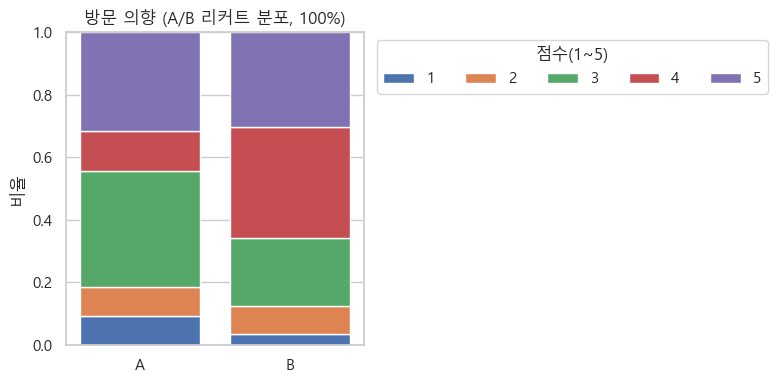

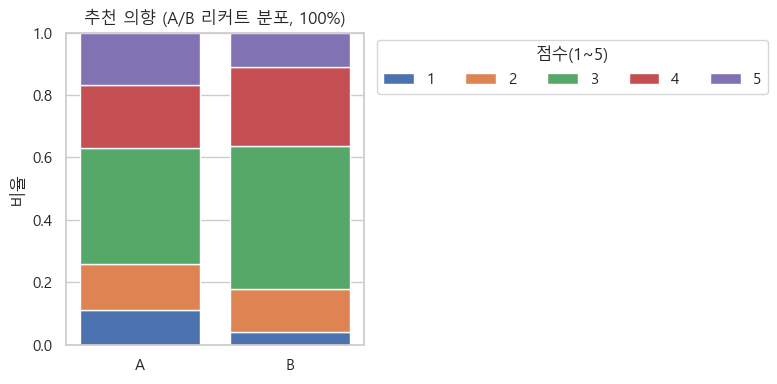

In [13]:
# 6) 시각화 1: 100% 누적 막대 (리커트 분포)
# -------------------------
def plot_likert_stacked(df, score_col, title):
    # 1~5 분포
    dist = (
        df.groupby("group")[score_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=[1,2,3,4,5], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(8,4))
    bottom = np.zeros(len(dist))

    for s in dist.columns:
        vals = dist[s].values
        ax.bar(dist.index, vals, bottom=bottom, label=str(s))
        bottom += vals

    ax.set_title(title + " (A/B 리커트 분포, 100%)")
    ax.set_ylabel("비율")
    ax.set_ylim(0, 1)
    ax.legend(title="점수(1~5)", ncol=5, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_likert_stacked(df_ab, "reserve_perception_change", "방문 의향")
plot_likert_stacked(df_ab, "reserve_recommend", "추천 의향")

***

C:\Users\won24\AppData\Local\Temp\ipykernel_17288\2296144465.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["A 집단","B 집단"], showmeans=True)


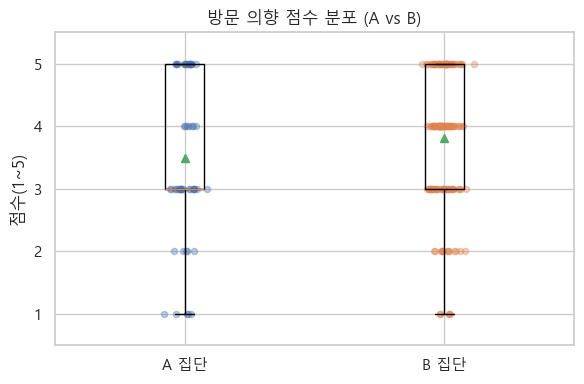

C:\Users\won24\AppData\Local\Temp\ipykernel_17288\2296144465.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["A 집단","B 집단"], showmeans=True)


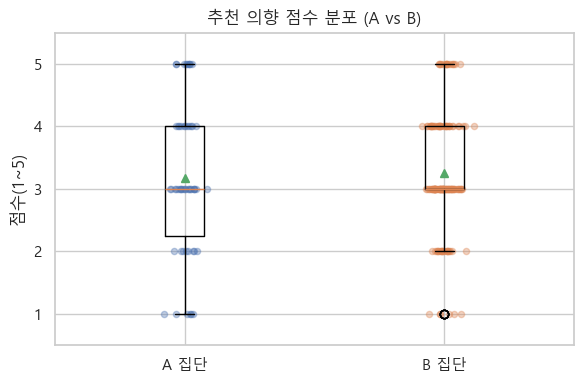

In [14]:
# 7) 시각화 2: 박스플롯 + 점도
def box_with_jitter(df, col, title):
    a = df.loc[df["group"]=="A", col]
    b = df.loc[df["group"]=="B", col]

    fig, ax = plt.subplots(figsize=(6,4))
    ax.boxplot([a, b], labels=["A 집단","B 집단"], showmeans=True)

    # 점도(지터)
    rng = np.random.default_rng(42)
    ax.scatter(1 + rng.normal(0, 0.04, size=len(a)), a, alpha=0.35, s=20)
    ax.scatter(2 + rng.normal(0, 0.04, size=len(b)), b, alpha=0.35, s=20)

    ax.set_title(title)
    ax.set_ylabel("점수(1~5)")
    ax.set_ylim(0.5, 5.5)
    plt.tight_layout()
    plt.show()

box_with_jitter(df_ab, "reserve_perception_change", "방문 의향 점수 분포 (A vs B)")
box_with_jitter(df_ab, "reserve_recommend", "추천 의향 점수 분포 (A vs B)")

***

#### 📌 가설: (H06-1, 2) 인사이트

> 1. `선호도`는 `A 집단(27%)`보다 `B 집단(73.0%)`이 압도적으로 `높다`.<br><br>
> 2. 그러나 `선호도`가 곧바로 `방문/추천 의향 점수 분포` 상승으로 `이어지진 않는다`.<br>
↪︎ 즉, `A 집단`을 고른 사람이나 `B 집단`을 고른 사람이나 `방문/추천 의향 점수`를 `비슷`하게 준다.<br><br>
> 3. 따라서 전략은 `유입(광고/썸네일)`: `B 집단 컨셉`(공간·스토리)으로 `클릭 유도/관심 선호도`를 확보.

***

#### 📌 가설: (H06-3, 4)
- (H06-3) `A 집단`과 `B 집단`의 `방문 의향 점수`에 대한 <span style="color:red">긍정(4~5점) 비율</span>과 <span style="color:skyblue">비긍정(1~3점) 비율</span>에 유의한 `차이가 없을 것이다`.<br><br>
- (H06-4) `A 집단`과 `B 집단`의 `추천 의향 점수`에 대한 <span style="color:red">긍정(4~5점) 비율</span>과 <span style="color:skyblue">비긍정(1~3점) 비율</span>에 유의한 `차이가 없을 것이다`.

##### 💡 검정: 카이제곱
  - `목적`: “긍정(4~5)” 비율이 집단(A/B)에 따라 달라지는지 검정.
  - `이유`: 평균/중앙값은 비슷해도 “상위 긍정 비율”에서만 차이가 날 수 있으므로 비율 차이를 확인하기 위한 분석.
  - `해석`:
    - 차이가 크면 → chi2 값 커짐
    - 차이가 작으면 → chi2 값 작아짐
    - p < 0.05 → 유의한 차이가 있다(귀무가설 기각)
    - p ≥ 0.05 → 유의한 차이라고 보기 어렵다(귀무가설 기각 실패)

In [15]:
# 8) 카이제곱에(Cramér’s V, 표준화 잔차)
# 4~5점 = 긍정(1) / 1~3점 = 비긍정(0)

def chi_square_topbox(df, score_col, threshold=4):
    tmp = df.copy()
    tmp["topbox"] = np.where(tmp[score_col] >= threshold, 1, 0)

    # 교차표: group(A/B) x topbox(0/1)
    ctab = pd.crosstab(tmp["group"], tmp["topbox"]).reindex(columns=[1, 0], fill_value=0)

    chi2, p, dof, expected = stats.chi2_contingency(ctab)

    A1, A0 = ctab.loc["A", 1], ctab.loc["A", 0]
    B1, B0 = ctab.loc["B", 1], ctab.loc["B", 0]

    pA = A1 / (A0 + A1) if (A0 + A1) > 0 else np.nan
    pB = B1 / (B0 + B1) if (B0 + B1) > 0 else np.nan
    rd = pB - pA

    return ctab, chi2, p, dof, expected, pA, pB, rd

# Cramér’s V - 크래머 V계수(효과크기)
def cramers_v(ctab, chi2, n):
    # 2x2이면 V = sqrt(chi2 / n)
    return np.sqrt(chi2 / n)

# 표준화 잔차(어디서 차이가 났는지)
def standardized_residuals(ctab, expected):
    obs = ctab.to_numpy()
    resid = (obs - expected) / np.sqrt(expected)
    return pd.DataFrame(resid, index=ctab.index, columns=ctab.columns)

# 방문 의향
ct1, chi1, p1, dof1, exp1, pA1, pB1, rd1 = chi_square_topbox(df_ab, "reserve_perception_change", threshold=4)

# 추천 의향
ct2, chi2, p2, dof2, exp2, pA2, pB2, rd2 = chi_square_topbox(df_ab, "reserve_recommend", threshold=4)

n1 = ct1.to_numpy().sum()
v1 = cramers_v(ct1, chi1, n1)

n2 = ct2.to_numpy().sum()
v2 = cramers_v(ct2, chi2, n2)

resid1 = standardized_residuals(ct1, exp1)

resid2 = standardized_residuals(ct2, exp2)

print("\n[카이제곱 Top-box] 방문 의향 (4~5):")
print(ct1)
print(f"A topbox={pA1:.3f}, B topbox={pB1:.3f}, 차이(B-A)={rd1:.3f}")
print(f"chi2={chi1:.3f}, p={p1:.5f}")
print("Cramér’s V=", round(v1, 3))
print("\n표준화 잔차")
print(resid1)

print("------------------------------")

print("\n[카이제곱 Top-box] 추천 의향 (4~5):")
print(ct2)
print(f"A topbox={pA2:.3f}, B topbox={pB2:.3f}, 차이(B-A)={rd2:.3f}")
print(f"chi2={chi2:.3f}, p={p2:.5f}")
print("Cramér’s V=", round(v2, 3))
print("\n표준화 잔차")
print(resid2)


[카이제곱 Top-box] 방문 의향 (4~5):
topbox   1   0
group         
A       24  30
B       96  50
A topbox=0.444, B topbox=0.658, 차이(B-A)=0.213
chi2=6.597, p=0.01022
Cramér’s V= 0.182

표준화 잔차
topbox         1         0
group                     
A      -1.475730  1.807392
B       0.897485 -1.099190
------------------------------

[카이제곱 Top-box] 추천 의향 (4~5):
topbox   1   0
group         
A       20  34
B       53  93
A topbox=0.370, B topbox=0.363, 차이(B-A)=-0.007
chi2=0.000, p=1.00000
Cramér’s V= 0.0

표준화 잔차
topbox         1         0
group                     
A       0.065321 -0.049524
B      -0.039726  0.030119


#### ☑️ 카이제곱 검정 정리
1. [카이제곱 Top-box] 집단(A/B) <span style="color:orange">방문 의향 긍정(4~5점)</span>

- <span style="color:red">**긍정(4~5점)**</span> 비율 차이=`21.3%`

|group|<span style="color:red">긍정(topbox=1)</span>|<span style="color:skyblue">비긍정(topbox=0)</span>|
|:---:|:---:|:---:|
|A|24개(`44.4%`)|30개(`55.6%`)|
|B|96개(`65.8%`)|50개(`34.2%`)|

- chi2, p-value, Cramér’s V

|chi2값|p값|크래머 V계수(효과크기)|
|:---:|:---:|:---:|
|6.59|0.01|0.18|

- 표준화 잔차(어디서 차이가 났는지)

|group|<span style="color:red">긍정(topbox=1)</span>|<span style="color:skyblue">비긍정(topbox=0)</span>|
|:---:|:---:|:---:|
|A|-1.475730|1.807392|
|B|0.897485|-1.099190|

***

2. [카이제곱 Top-box] 집단(A/B) <span style="color:orange">추천 의향 긍정(4~5점)</span>

<span style="color:red">**긍정(4~5점)**</span> 비율 차이=`0.7%`

|group|<span style="color:red">긍정(topbox=1)</span>|<span style="color:skyblue">비긍정(topbox=0)</span>|
|:---:|:---:|:---:|
|A|20개(`37.0%`)|34개(`63.0%`)|
|B|53개(`36.3%`)|93개(`63.7%`)|

- chi2, p-value, Cramér’s V

|chi2값|p값|크래머 V계수(효과크기)|
|:---:|:---:|:---:|
|0.00|1.00|0.00|

- 표준화 잔차(어디서 차이가 났는지)

|group|<span style="color:red">긍정(topbox=1)</span>|<span style="color:skyblue">비긍정(topbox=0)</span>|
|:---:|:---:|:---:|
|A|0.065321|-0.049524|
|B|-0.039726|-0.039726|

***

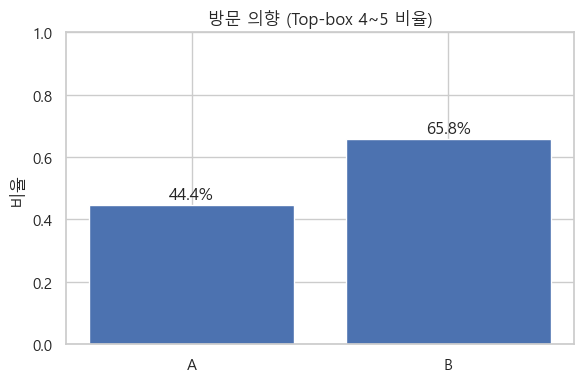

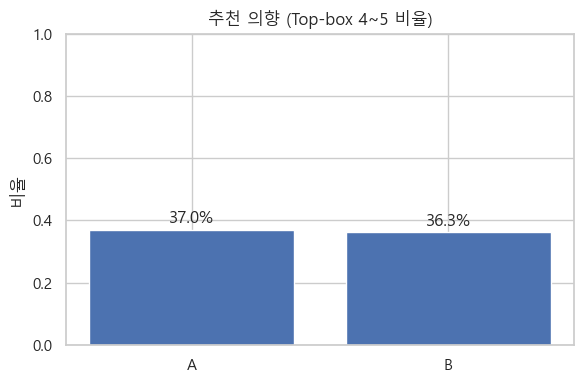

In [16]:
# 9) 시각화 3: Top-box(4~5) 비율 막대그래프
# -------------------------
def plot_topbox(df, score_col, title, threshold=4):
    rate = df.groupby("group")[score_col].apply(lambda s: (s >= threshold).mean())

    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(rate.index, rate.values)
    ax.set_title(title + f" (Top-box {threshold}~5 비율)")
    ax.set_ylabel("비율")
    ax.set_ylim(0, 1)
    for i, v in enumerate(rate.values):
        ax.text(i, v+0.02, f"{v*100:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

plot_topbox(df_ab, "reserve_perception_change", "방문 의향")
plot_topbox(df_ab, "reserve_recommend", "추천 의향")

***

#### 📌 가설: (H06-3, 4) 인사이트

> 1. 집단(A/B)의 `방문 의향 점수`에 대한 `긍정 비율`에서 `유의한 차이가 확인`된다.<br><br>
> 2. 반면 집단(A/B)의 `추천 의향 점수`에 대한 `긍정 비율`에서 `유의한 차이는 확인되지 않는다`.

***

#### 📌 최종 인사이트

> 1. `선호도(선택)`는 `A 집단(27%)`보다 `B 집단(73.0%)`이 압도적으로 <span style="color:red">높았음</span>.<br>
↪︎ `유입률`을 높이기 위해선 B 집단 컨셉`(공간·스토리)으로`클릭 유도 및 관심 선호도를 확보.<br><br>
> 2. `[방문 의향 점수 분포]`는 `기술통계상` 평균/중앙값 차이는 <span style="color:red">크지 않았음</span>.<br>
-> 또한, `Mann–Whitney U 검정 결과`에서도(p=0.11) `집단(A/B)의 “전체 점수 분포가 다르다”`라고 말하기엔 <span style="color:red">어려움</span>.<br>
-> 다만 `카이제곱 검정 결과`(Top-box p=0.01, V=0.18)<br>`“Top-box(4~5) 비율`은 `B: 65.8%, A: 44.4%`로 차이가 있었고 차이는 <span style="color:red">‘강한 긍정(4~5) 비율’</span> 구간에서 발생했음.<br>
↪︎ 즉, 집단 B는 `‘한번 가볼까?’` 수준을 넘어 `“가고 싶다(상위 점수)”`로 답 할수 있음.<br><br>
> 3. `[추천 의향 점수 분포]`는 `기술통계`, `Mann–Whitney U 검정`, `카이제곱 검정` 결과 모두 <span style="color:red">A/B 차이가 없었음.</span><br>
↪︎ 방문 설득과 추천 설득은 다른 문제였음.<br>
즉, `B 집단 컨셉`로 `‘가고 싶게’`는 만들 수 있지만, `‘남에게 추천’`까지 해주기에는 <span style="color:red">어려움</span>.<br><br>
> 4. `전략 제안`<br>
↪︎ 1) `유입/관심`: <span style="color:skyblue">기존 스타벅스 리저브</span>는 `A 집단 메세지`를 `추구`.<br>
그러나 <span style="color:skyblue">A/B 테스트 결과</span> `B 집단 메세지`가 <span style="color:red">유리</span>.<br>
따라서 <span style="color:skyblue">기존 스타벅스 리저브의 목적</span>인 `A 집단 메세지`와 <span style="color:skyblue">A/B 테스트 결과</span>에서 나온 `B 집단 메세지`를 `융합` 시키면 <span style="color:red">더욱 더 유입률을 높일 수 있음</span>.<br><br>
↪︎ 2) `추천/확산`: <span style="color:orange">*메시지</span> 말고 `추천 트리거(혜택/동행/공유)`를 <span style="color:red">별도 설계</span>해야 함.<br><br>
<span style="color:orange">*메세지</span><br>
A안 - 프리미엄 커피/전문성(원두·추출) : 원두 종류 다양성 + 바,<br>
B안 - 목적지형 : 공간·인테리어 / 지역성·스토리

***